# Vietnamese Handwriting OCR - Kaggle Fine-tune + Resume



In [1]:
import os
import sys
import re
import io
import csv
import math
import time
import json
import shutil
import zipfile
import hashlib
import random
import string
import warnings
import pkgutil
import subprocess
from pathlib import Path

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

def ensure_package(package_name: str, import_name: str | None = None) -> None:
    import_name = import_name or package_name
    if pkgutil.find_loader(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

ensure_package("editdistance")
ensure_package("scikit-learn", "sklearn")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import editdistance
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K
from tensorflow.keras import mixed_precision
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

try:
    tf.config.optimizer.set_experimental_options({"layout_optimizer": False})
except Exception as exc:
    print("layout_optimizer config skipped:", exc)

if gpus:
    mixed_precision.set_global_policy("mixed_float16")

strategy = tf.distribute.MirroredStrategy() if len(gpus) > 1 else tf.distribute.get_strategy()

print("TensorFlow:", tf.__version__)
print("GPUs      :", len(gpus))
print("Strategy  :", type(strategy).__name__)
print("Policy    :", mixed_precision.global_policy())


2026-03-20 11:39:46.407688: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774006786.849097      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774006787.002149      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774006787.971795      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774006787.971850      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774006787.971853      23 computation_placer.cc:177] computation placer alr

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
TensorFlow: 2.19.0
GPUs      : 2
Strategy  : MirroredStrategy
Policy    : <DTypePolicy "mixed_float16">


I0000 00:00:1774006822.733699      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774006822.739568      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [2]:
CFG = {
    "run_mode": "profile_export",
    "target_height": 96,
    "downsample_factor": 4,
    "per_device_batch_size": 2,
    "initial_lr": 3e-5,
    "val_size": 0.12,
    "max_width": 2048,
    "min_width": 64,
    "width_pad_multiple": 16,
    "fixed_train_width": 1792,
    "fixed_eval_width": 1792,
    "blend_alpha_candidates": [0.20, 0.35, 0.50],
    "default_export_alpha": 0.35,
    "preview_samples": 6,
    "decoder": "greedy",
    "beam_width": 10,
    "dataset_root": "/kaggle/input/datasets/huyyuh/3500-w/vn_handwritten_images",
    "weights_path": "/kaggle/input/models/trinhminhkhoak18hcm/ocr-train-chuan-checkpoint-weights/gguf/default/1/ocr-train-chuan_checkpoint.weights.h5",
    "resume_artifact": "/kaggle/input/resume_bundle",
    "camera_hard_eval_root": None,
    "camera_hard_sample_size": 256,
    "camera_hard_enabled": True,
    "output_root": "/kaggle/working/ocr_profile_run",
}

CFG["global_batch_size"] = CFG["per_device_batch_size"] * strategy.num_replicas_in_sync
OUTPUT_ROOT = Path(CFG["output_root"])
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

PATHS = {
    "metadata_cache": OUTPUT_ROOT / "ocr_metadata_cache.csv",
    "baseline_weights": OUTPUT_ROOT / "profile_clean_baseline.weights.h5",
    "balanced_weights": OUTPUT_ROOT / "profile_robust_balanced.weights.h5",
    "default_blend_weights": OUTPUT_ROOT / "profile_compromise_a35.weights.h5",
    "alpha20_weights": OUTPUT_ROOT / "profile_blend_a20.weights.h5",
    "alpha50_weights": OUTPUT_ROOT / "profile_blend_a50.weights.h5",
    "config_json": OUTPUT_ROOT / "run_config.json",
    "profile_report_json": OUTPUT_ROOT / "profile_report.json",
    "bundle_zip": OUTPUT_ROOT / "resume_bundle.zip",
    "export_model": OUTPUT_ROOT / "ocr_inference.keras",
    "metrics_dir": OUTPUT_ROOT / "metrics",
    "predictions_dir": OUTPUT_ROOT / "predictions",
}

PATHS["metrics_dir"].mkdir(parents=True, exist_ok=True)
PATHS["predictions_dir"].mkdir(parents=True, exist_ok=True)

with open(PATHS["config_json"], "w", encoding="utf-8") as f:
    json.dump(CFG, f, ensure_ascii=False, indent=2)

print(json.dumps(CFG, ensure_ascii=False, indent=2))


{
  "run_mode": "profile_export",
  "target_height": 96,
  "downsample_factor": 4,
  "per_device_batch_size": 2,
  "initial_lr": 3e-05,
  "val_size": 0.12,
  "max_width": 2048,
  "min_width": 64,
  "width_pad_multiple": 16,
  "fixed_train_width": 1792,
  "fixed_eval_width": 1792,
  "blend_alpha_candidates": [
    0.2,
    0.35,
    0.5
  ],
  "default_export_alpha": 0.35,
  "preview_samples": 6,
  "decoder": "greedy",
  "beam_width": 10,
  "dataset_root": "/kaggle/input/datasets/huyyuh/3500-w/vn_handwritten_images",
  "weights_path": "/kaggle/input/models/trinhminhkhoak18hcm/ocr-train-chuan-checkpoint-weights/gguf/default/1/ocr-train-chuan_checkpoint.weights.h5",
  "resume_artifact": "/kaggle/input/resume_bundle",
  "camera_hard_eval_root": null,
  "camera_hard_sample_size": 256,
  "camera_hard_enabled": true,
  "output_root": "/kaggle/working/ocr_profile_run",
  "global_batch_size": 4
}


In [3]:
SEARCH_ROOTS = [Path("/kaggle/input"), Path("/kaggle/working"), Path.cwd()]

def existing_search_roots():
    return [root for root in SEARCH_ROOTS if root.exists()]

def maybe_unpack_resume_bundle(manual_path=None):
    if manual_path:
        bundle = Path(manual_path)
        if bundle.is_file() and bundle.suffix.lower() == ".zip":
            target = OUTPUT_ROOT / "resume_bundle_input"
            if target.exists():
                shutil.rmtree(target)
            target.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(bundle, "r") as zf:
                zf.extractall(target)
            return target
        if bundle.is_dir():
            return bundle

    for root in existing_search_roots():
        for bundle in root.rglob("resume_bundle.zip"):
            target = OUTPUT_ROOT / "resume_bundle_input"
            if target.exists():
                shutil.rmtree(target)
            target.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(bundle, "r") as zf:
                zf.extractall(target)
            return target

    # Support the case where the user uploaded the extracted resume folder as a dataset.
    for root in existing_search_roots():
        for balanced_path in root.rglob("best_balanced.weights.h5"):
            parent = balanced_path.parent
            if (parent / "best.weights.h5").exists():
                return parent
    return None

def discover_dataset_root(manual_path=None):
    if manual_path:
        root = Path(manual_path)
        if (root / "labels.json").exists() and (root / "data").exists():
            return root
        raise FileNotFoundError(f"Dataset root khong hop le: {root}")

    candidates = []
    for root in existing_search_roots():
        for labels_path in root.rglob("labels.json"):
            dataset_root = labels_path.parent
            if (dataset_root / "data").exists():
                score = 0
                lower = str(dataset_root).lower()
                if "vn_handwritten_images" in lower:
                    score += 5
                if "hand" in lower or "written" in lower:
                    score += 2
                candidates.append((score, str(dataset_root), dataset_root))
    if not candidates:
        raise FileNotFoundError("Khong tim thay dataset co labels.json va data/")
    candidates.sort(key=lambda x: (-x[0], x[1]))
    return candidates[0][2]

def discover_weights(manual_path=None):
    if manual_path:
        p = Path(manual_path)
        if p.exists():
            return p
        raise FileNotFoundError(f"Khong tim thay weights: {p}")

    preferred = {
        "ocr-train-chuan_checkpoint.weights.h5": 8,
        "best.weights.h5": 6,
        "latest.weights.h5": 5,
    }
    candidates = []
    for root in existing_search_roots():
        for path in root.rglob("*.h5"):
            if not path.is_file():
                continue
            score = preferred.get(path.name, 0)
            low = path.name.lower()
            if "checkpoint" in low:
                score += 2
            if "best" in low:
                score += 2
            if "ocr" in low:
                score += 1
            candidates.append((score, str(path), path))
    if not candidates:
        return None
    candidates.sort(key=lambda x: (-x[0], x[1]))
    return candidates[0][2]

def discover_resume_dir(preferred_root=None):
    search_roots = []
    if preferred_root and Path(preferred_root).exists():
        search_roots.append(Path(preferred_root))
    search_roots.extend(existing_search_roots())

    candidates = []
    for root in search_roots:
        for ckpt_marker in root.rglob("checkpoint"):
            ckpt_dir = ckpt_marker.parent
            if list(ckpt_dir.glob("ckpt-*.index")):
                score = 0
                if "resume" in str(ckpt_dir).lower():
                    score += 3
                if "ocr" in str(ckpt_dir).lower():
                    score += 1
                candidates.append((score, str(ckpt_dir), ckpt_dir))
    if not candidates:
        return None
    candidates.sort(key=lambda x: (-x[0], x[1]))
    return candidates[0][2]

def discover_camera_hard_root(manual_path=None):
    if manual_path:
        root = Path(manual_path)
        if (root / "labels.json").exists() and (root / "data").exists():
            return root
        raise FileNotFoundError(f"camera_hard_eval_root khong hop le: {root}")
    return None

RESUME_INPUT_ROOT = maybe_unpack_resume_bundle(CFG["resume_artifact"])
DATASET_ROOT = discover_dataset_root(CFG["dataset_root"])
LABELS_PATH = DATASET_ROOT / "labels.json"
IMAGE_DIR = DATASET_ROOT / "data"
WEIGHTS_PATH = discover_weights(CFG["weights_path"])
RESUME_DIR = discover_resume_dir(RESUME_INPUT_ROOT)
CAMERA_HARD_ROOT = discover_camera_hard_root(CFG["camera_hard_eval_root"])

print("DATASET_ROOT     =", DATASET_ROOT)
print("WEIGHTS_PATH     =", WEIGHTS_PATH)
print("RESUME_INPUT_ROOT=", RESUME_INPUT_ROOT)
print("RESUME_DIR       =", RESUME_DIR)
print("CAMERA_HARD_ROOT =", CAMERA_HARD_ROOT)


DATASET_ROOT     = /kaggle/input/datasets/huyyuh/3500-w/vn_handwritten_images
WEIGHTS_PATH     = /kaggle/input/models/trinhminhkhoak18hcm/ocr-train-chuan-checkpoint-weights/gguf/default/1/ocr-train-chuan_checkpoint.weights.h5
RESUME_INPUT_ROOT= /kaggle/input/datasets/trinhminhkhoak18hcm/resume-bundle
RESUME_DIR       = /kaggle/input/datasets/trinhminhkhoak18hcm/resume-bundle/resume_ckpt
CAMERA_HARD_ROOT = None


In [4]:
with open(LABELS_PATH, "r", encoding="utf-8") as f:
    raw_labels = json.load(f)

def build_legacy_charset():
    vietnamese_vowels = [
        "a","à","á","ả","ã","ạ","ă","ằ","ắ","ẳ","ẵ","ặ","â","ầ","ấ","ẩ","ẫ","ậ",
        "e","è","é","ẻ","ẽ","ẹ","ê","ề","ế","ể","ễ","ệ",
        "i","ì","í","ỉ","ĩ","ị",
        "o","ò","ó","ỏ","õ","ọ","ô","ồ","ố","ổ","ỗ","ộ","ơ","ờ","ớ","ở","ỡ","ợ",
        "u","ù","ú","ủ","ũ","ụ","ư","ừ","ứ","ử","ữ","ự",
        "y","ỳ","ý","ỷ","ỹ","ỵ"
    ]
    vietnamese_consonants = ["b","c","d","đ","g","h","k","l","m","n","p","q","r","s","t","v","x"]
    upper_vowels = [c.upper() for c in vietnamese_vowels]
    upper_consonants = [c.upper() for c in vietnamese_consonants]
    digits = list("0123456789")
    punctuation = [" ", ".", ",", ":", ";", "!", "?", "-", "_", "(", ")", "[", "]", "/", "%", "&", "*", "=", "@", "$", "'", "\""]
    extra_chars = ["f", "j", "w", "z", "F", "J", "W", "Z", "#", "+"]
    return sorted(set(vietnamese_vowels + vietnamese_consonants + upper_vowels + upper_consonants + digits + punctuation + extra_chars))

char_list = build_legacy_charset()
char_to_idx = {c: i for i, c in enumerate(char_list)}
idx_to_char = {i: c for i, c in enumerate(char_list)}

dataset_chars = sorted(set("".join(raw_labels.values())))
missing_chars = sorted(set(dataset_chars) - set(char_list))
if missing_chars:
    raise ValueError(f"Dataset co ky tu ngoai legacy charset: {missing_chars[:20]}")

def encode_text(text: str):
    return [char_to_idx[c] for c in text if c in char_to_idx]

def build_source_group(filename: str) -> str:
    stem = Path(filename).stem
    if stem.endswith("_samples"):
        return f"samples:{stem.replace('_samples', '')}"
    if "_" in stem:
        first = stem.split("_")[0]
        if first.isdigit():
            return f"crop:{first}"
    if stem.isdigit():
        return f"single:{stem}"
    return f"misc:{stem}"

cache_path = PATHS["metadata_cache"]
use_cache = False
if cache_path.exists():
    cached = pd.read_csv(cache_path)
    if not cached.empty and "dataset_root" in cached.columns and str(cached["dataset_root"].iloc[0]) == str(DATASET_ROOT):
        records_df = cached.copy()
        use_cache = True

if not use_cache:
    rows = []
    for filename, text in raw_labels.items():
        image_path = IMAGE_DIR / filename
        if not image_path.exists():
            continue
        try:
            with Image.open(image_path) as img:
                width, height = img.size
        except Exception:
            continue
        scaled_width = int(round(width * CFG["target_height"] / max(1, height)))
        scaled_width = max(CFG["min_width"], min(CFG["max_width"], scaled_width))
        rows.append(
            {
                "dataset_root": str(DATASET_ROOT),
                "filename": filename,
                "path": str(image_path),
                "text": text,
                "label_length": len(text),
                "orig_width": width,
                "orig_height": height,
                "scaled_width": scaled_width,
                "source_group": build_source_group(filename),
            }
        )
    records_df = pd.DataFrame(rows)
    records_df.to_csv(cache_path, index=False, encoding="utf-8-sig")

records_df["required_width"] = (records_df["label_length"] + 2) * CFG["downsample_factor"]
records_df["encoded"] = records_df["text"].apply(encode_text)
records_df["encoded_length"] = records_df["encoded"].apply(len)
records_df["final_width_hint"] = records_df[["scaled_width", "required_width"]].max(axis=1)
records_df["length_bin"] = pd.cut(
    records_df["label_length"],
    bins=[-1, 10, 25, 50, 75, 100, 1000],
    labels=["<=10", "11-25", "26-50", "51-75", "76-100", ">100"],
)

splitter = GroupShuffleSplit(n_splits=1, test_size=CFG["val_size"], random_state=SEED)
train_idx, val_idx = next(splitter.split(records_df, groups=records_df["source_group"]))
train_df = records_df.iloc[train_idx].reset_index(drop=True)
val_df = records_df.iloc[val_idx].reset_index(drop=True)

print("All samples :", len(records_df))
print("Train samples:", len(train_df))
print("Val samples  :", len(val_df))
print("Unique train groups:", train_df["source_group"].nunique())
print("Unique val groups  :", val_df["source_group"].nunique())

group_overlap = set(train_df["source_group"]) & set(val_df["source_group"])
print("Shared groups:", len(group_overlap))

display(records_df.head(3))
display(pd.concat(
    [
        train_df["length_bin"].value_counts(normalize=True).rename("train_ratio"),
        val_df["length_bin"].value_counts(normalize=True).rename("val_ratio"),
    ],
    axis=1,
).fillna(0.0))


All samples : 15267
Train samples: 13944
Val samples  : 1323
Unique train groups: 2231
Unique val groups  : 305
Shared groups: 0


,dataset_root,filename,path,text,label_length,orig_width,orig_height,scaled_width,source_group,required_width,encoded,encoded_length,final_width_hint,length_bin
0,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,1.jpg,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,"Số 3 Nguyễn Ngọc Vũ, Hà Nội",27,1684,245,660,single:1,116,"[49, 179, 0, 19, 0, 44, 66, 80, 84, 167, 73, 0...",27,660,26-50
1,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,2.jpg,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,"Số 30 Nguyên Hồng, Láng Hạ, Đống Đa, Hà Nội",43,2030,276,706,single:2,180,"[49, 179, 0, 19, 16, 0, 44, 66, 80, 84, 108, 7...",43,706,26-50
2,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,3.jpg,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,"58 Thái Thịnh, Đống Đa, Hà Nội",30,2544,376,650,single:3,128,"[21, 24, 0, 50, 67, 103, 68, 0, 50, 67, 173, 7...",30,650,26-50


,train_ratio,val_ratio
length_bin,,
51-75,0.358003,0.363568
<=10,0.233362,0.288738
26-50,0.203385,0.201814
76-100,0.164730,0.117158
11-25,0.036862,0.027967
>100,0.003657,0.000756


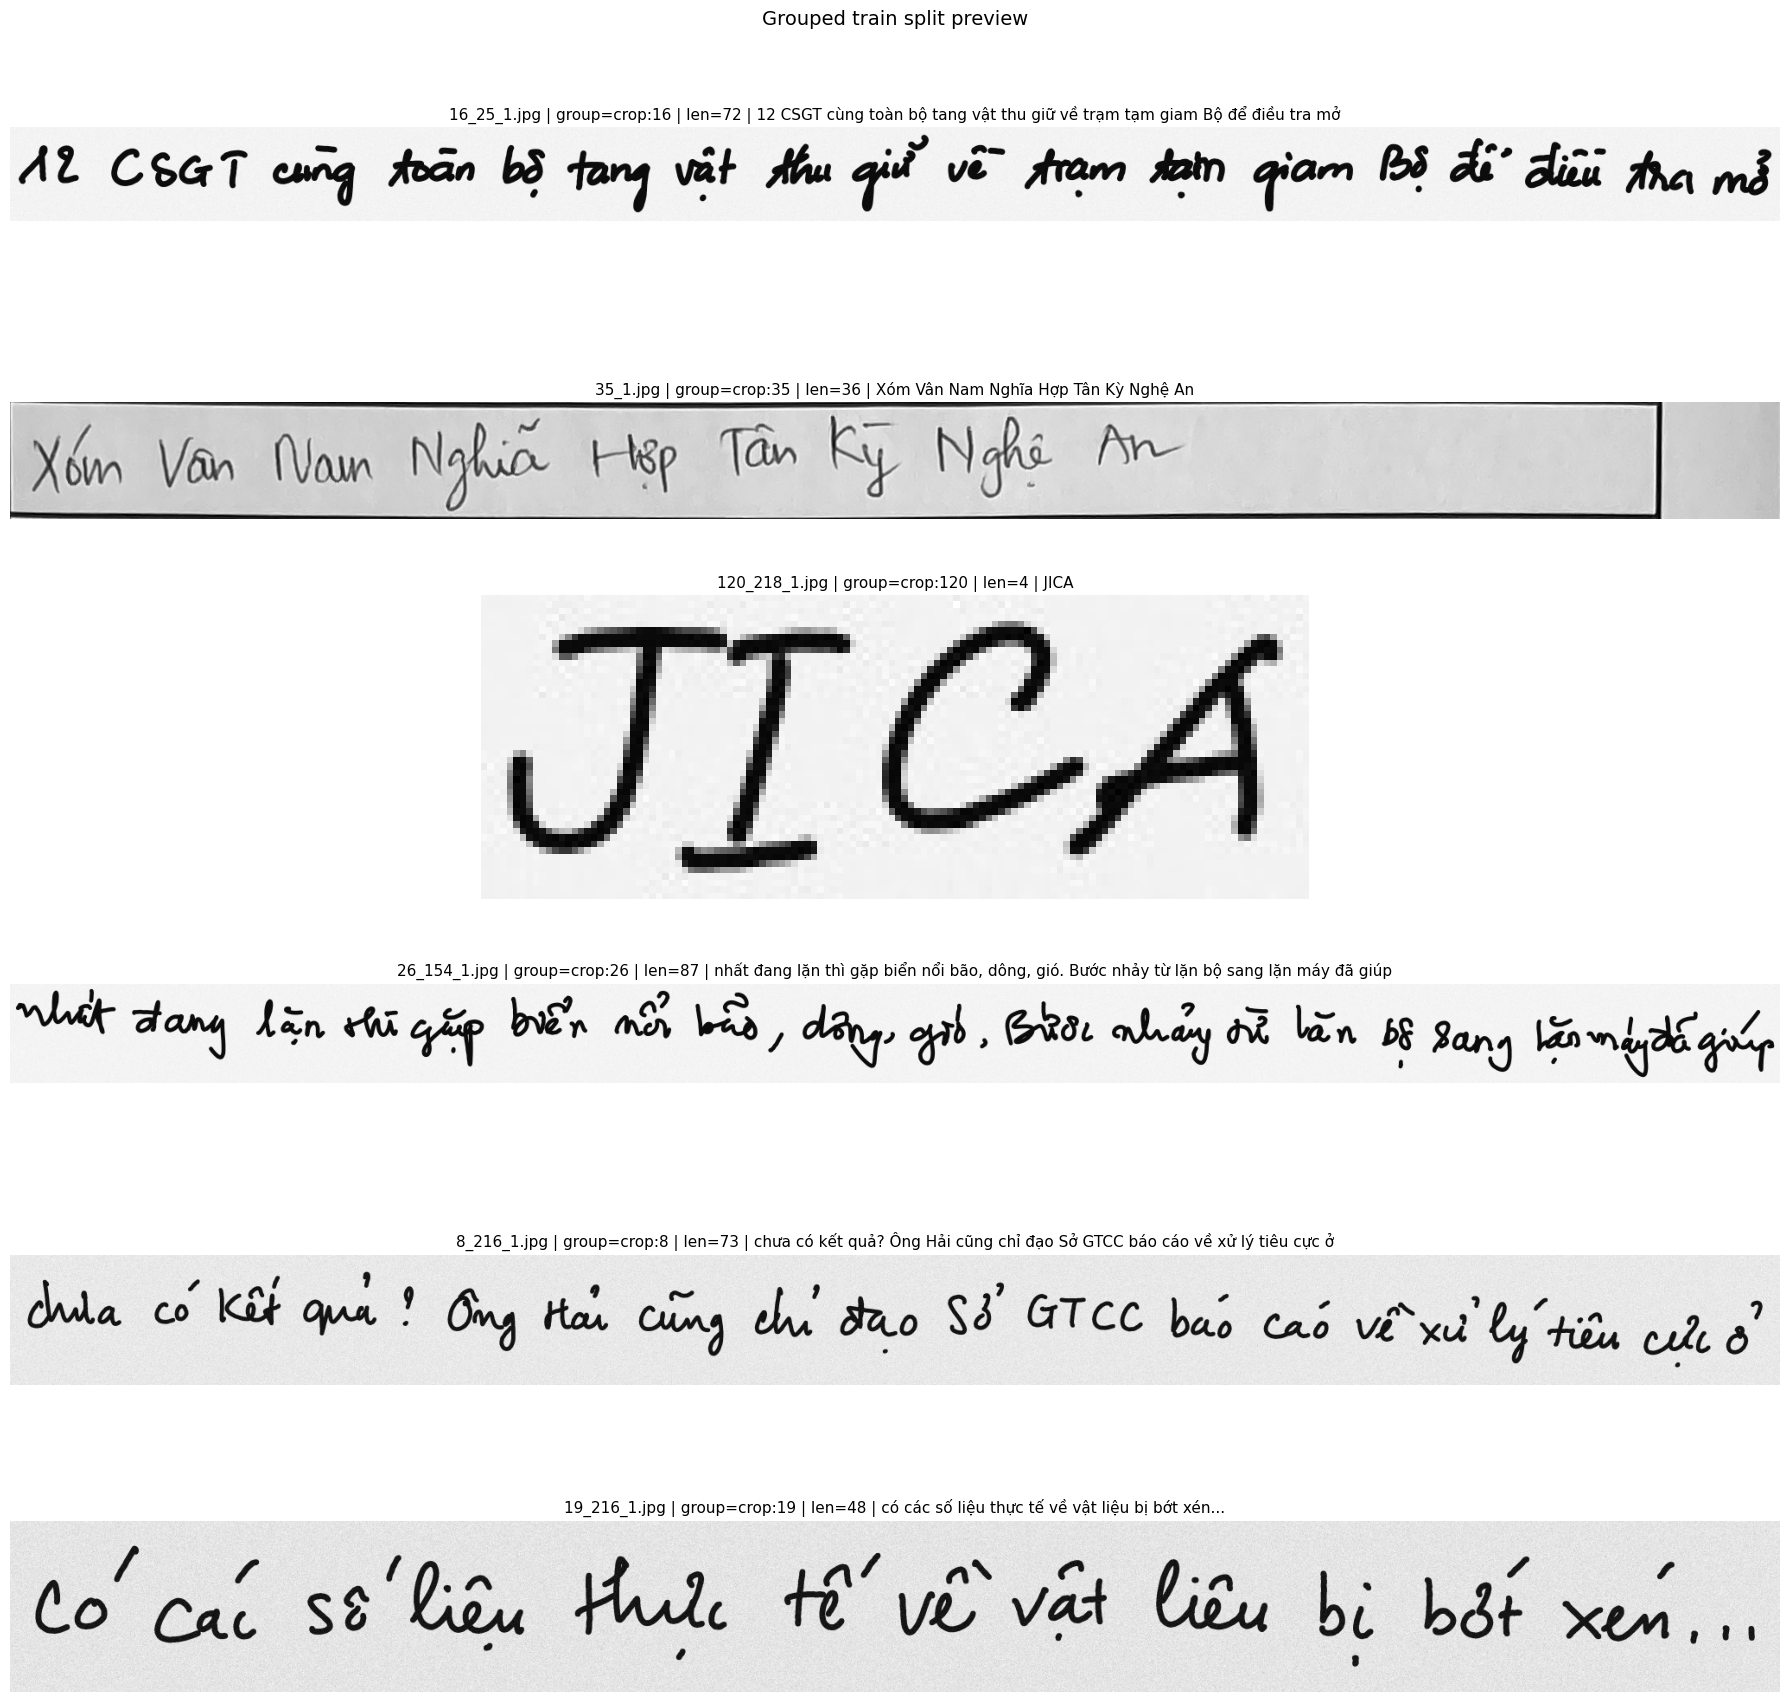

In [5]:
def show_dataset_samples(df, title, n=6, seed=SEED):
    sample_df = df.sample(min(n, len(df)), random_state=seed).reset_index(drop=True)
    fig, axes = plt.subplots(len(sample_df), 1, figsize=(18, 3 * len(sample_df)))
    if len(sample_df) == 1:
        axes = [axes]
    for ax, row in zip(axes, sample_df.itertuples()):
        img = cv2.imread(row.path, cv2.IMREAD_GRAYSCALE)
        ax.imshow(img, cmap="gray")
        ax.set_title(f"{row.filename} | group={row.source_group} | len={row.label_length} | {row.text}", fontsize=11)
        ax.axis("off")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

show_dataset_samples(train_df, "Grouped train split preview", n=CFG["preview_samples"])


## Preprocess, hard augmentation, camera-hard evaluation



In [6]:
def stable_int_seed(text: str) -> int:
    return int(hashlib.md5(text.encode("utf-8")).hexdigest()[:8], 16)

def align_width(width: int, multiple: int) -> int:
    return int(math.ceil(width / multiple) * multiple)

def add_shadow(gray: np.ndarray, rng: np.random.Generator, hard: bool) -> np.ndarray:
    h, w = gray.shape
    x = np.linspace(0, 1, w, dtype=np.float32)
    y = np.linspace(0, 1, h, dtype=np.float32)
    xv, yv = np.meshgrid(x, y)
    mask = xv if rng.random() < 0.5 else yv
    if rng.random() < 0.5:
        mask = 1.0 - mask
    strength = rng.uniform(0.20, 0.65) if hard else rng.uniform(0.35, 0.75)
    shadow = strength + (1.0 - strength) * mask
    out = gray.astype(np.float32) * shadow
    return np.clip(out, 0, 255).astype(np.uint8)

def add_glare(gray: np.ndarray, rng: np.random.Generator, hard: bool) -> np.ndarray:
    h, w = gray.shape
    canvas = gray.astype(np.float32).copy()
    for _ in range(1 if not hard else 2):
        center = (int(rng.integers(0, w)), int(rng.integers(0, h)))
        radius = int(rng.integers(max(20, w // 10), max(30, w // 4)))
        overlay = np.zeros_like(canvas)
        cv2.circle(overlay, center, radius, 255, -1)
        alpha = rng.uniform(0.08, 0.18) if not hard else rng.uniform(0.15, 0.28)
        canvas = cv2.addWeighted(canvas, 1.0, overlay, alpha, 0.0)
    return np.clip(canvas, 0, 255).astype(np.uint8)

def add_stains(gray: np.ndarray, rng: np.random.Generator, hard: bool) -> np.ndarray:
    canvas = gray.astype(np.float32).copy()
    h, w = gray.shape
    num_blobs = int(rng.integers(3, 8 if not hard else 12))
    for _ in range(num_blobs):
        center = (int(rng.integers(0, w)), int(rng.integers(0, h)))
        axes = (
            int(rng.integers(max(8, w // 40), max(12, w // (8 if hard else 10)))),
            int(rng.integers(max(6, h // 8), max(8, h // (2 if hard else 3)))),
        )
        color = float(rng.integers(150 if hard else 170, 255))
        angle = float(rng.integers(0, 180))
        cv2.ellipse(canvas, center, axes, angle, 0, 360, color, -1)
    alpha = 0.18 if hard else 0.12
    mixed = cv2.addWeighted(gray.astype(np.float32), 1.0 - alpha, canvas, alpha, 0)
    return np.clip(mixed, 0, 255).astype(np.uint8)

def add_occlusion(gray: np.ndarray, rng: np.random.Generator, hard: bool) -> np.ndarray:
    out = gray.copy()
    h, w = out.shape
    num_boxes = int(rng.integers(1, 2 if not hard else 4))
    for _ in range(num_boxes):
        bw = int(rng.integers(max(12, w // 30), max(20, w // (8 if hard else 12))))
        bh = int(rng.integers(max(4, h // 12), max(6, h // (4 if hard else 6))))
        x = int(rng.integers(0, max(1, w - bw)))
        y = int(rng.integers(0, max(1, h - bh)))
        color = int(rng.integers(180, 255))
        cv2.rectangle(out, (x, y), (x + bw, y + bh), color, -1)
    return out

def random_motion_blur(gray: np.ndarray, rng: np.random.Generator, hard: bool) -> np.ndarray:
    k = int(rng.choice([3, 5, 7] if not hard else [5, 7, 9]))
    kernel = np.zeros((k, k), dtype=np.float32)
    if rng.random() < 0.5:
        kernel[k // 2, :] = 1.0
    else:
        kernel[:, k // 2] = 1.0
    kernel /= kernel.sum()
    return cv2.filter2D(gray, -1, kernel)

def random_perspective(gray: np.ndarray, rng: np.random.Generator, hard: bool) -> np.ndarray:
    h, w = gray.shape
    jitter_x = max(2, int(w * (0.03 if not hard else 0.06)))
    jitter_y = max(2, int(h * (0.08 if not hard else 0.14)))
    src = np.float32([[0, 0], [w - 1, 0], [0, h - 1], [w - 1, h - 1]])
    dst = src + np.float32([
        [rng.integers(-jitter_x, jitter_x + 1), rng.integers(-jitter_y, jitter_y + 1)],
        [rng.integers(-jitter_x, jitter_x + 1), rng.integers(-jitter_y, jitter_y + 1)],
        [rng.integers(-jitter_x, jitter_x + 1), rng.integers(-jitter_y, jitter_y + 1)],
        [rng.integers(-jitter_x, jitter_x + 1), rng.integers(-jitter_y, jitter_y + 1)],
    ]).astype(np.float32)
    matrix = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(gray, matrix, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=255)

def down_up_scale(gray: np.ndarray, rng: np.random.Generator, hard: bool) -> np.ndarray:
    h, w = gray.shape
    factor = rng.uniform(0.55, 0.85) if not hard else rng.uniform(0.35, 0.70)
    nw = max(32, int(w * factor))
    nh = max(24, int(h * factor))
    small = cv2.resize(gray, (nw, nh), interpolation=cv2.INTER_AREA)
    return cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)

def degrade_raw_image(gray: np.ndarray, rng: np.random.Generator, mode: str) -> np.ndarray:
    hard = mode == "hard_eval"
    img = gray.copy()

    if rng.random() < (0.30 if not hard else 0.55):
        img = random_perspective(img, rng, hard)

    if rng.random() < (0.85 if not hard else 0.95):
        alpha = float(rng.uniform(0.60, 1.35) if not hard else rng.uniform(0.45, 1.45))
        beta = float(rng.uniform(-45, 25) if not hard else rng.uniform(-70, 35))
        img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    if rng.random() < (0.50 if not hard else 0.80):
        gamma = float(rng.uniform(0.70, 1.60) if not hard else rng.uniform(0.55, 2.10))
        table = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype(np.uint8)
        img = cv2.LUT(img, table)

    if rng.random() < (0.55 if not hard else 0.90):
        if rng.random() < 0.5:
            k = int(rng.choice([3, 5] if not hard else [5, 7, 9]))
            img = cv2.GaussianBlur(img, (k, k), sigmaX=float(rng.uniform(0.5, 1.8) if not hard else rng.uniform(1.0, 3.0)))
        else:
            img = random_motion_blur(img, rng, hard)

    if rng.random() < (0.55 if not hard else 0.85):
        noise = rng.normal(0, float(rng.uniform(4, 18) if not hard else rng.uniform(10, 28)), size=img.shape)
        img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    if rng.random() < (0.30 if not hard else 0.55):
        img = down_up_scale(img, rng, hard)

    if rng.random() < (0.35 if not hard else 0.60):
        img = add_shadow(img, rng, hard)

    if rng.random() < (0.18 if not hard else 0.45):
        img = add_glare(img, rng, hard)

    if rng.random() < (0.22 if not hard else 0.50):
        img = add_stains(img, rng, hard)

    if rng.random() < (0.10 if not hard else 0.35):
        img = add_occlusion(img, rng, hard)

    if rng.random() < (0.20 if not hard else 0.40):
        quality = int(rng.integers(25, 65) if not hard else rng.integers(18, 45))
        ok, enc = cv2.imencode(".jpg", img, [int(cv2.IMWRITE_JPEG_QUALITY), quality])
        if ok:
            img = cv2.imdecode(enc, cv2.IMREAD_GRAYSCALE)

    return img

def remove_isolated_pixels(binary_inv: np.ndarray) -> np.ndarray:
    binary_map = (binary_inv > 0).astype(np.uint8)
    neighbors = cv2.filter2D(binary_map, -1, np.ones((3, 3), np.uint8))
    isolated = (binary_map == 1) & (neighbors <= 2)
    cleaned = binary_inv.copy()
    cleaned[isolated] = 0
    return cleaned

def preprocess_for_legacy_crnn(gray: np.ndarray, target_height: int, max_width: int, min_width: int, required_width: int | None, augment_mode: str, rng: np.random.Generator):
    img = gray.copy()
    if augment_mode in {"train", "hard_eval"}:
        img = degrade_raw_image(img, rng, augment_mode)

    h, w = img.shape
    new_w = int(round(w * target_height / max(1, h)))
    new_w = max(min_width, min(max_width, new_w))
    interpolation = cv2.INTER_AREA if new_w <= w else cv2.INTER_CUBIC
    img = cv2.resize(img, (new_w, target_height), interpolation=interpolation)

    background = cv2.medianBlur(img, 31)
    img = cv2.divide(img, background, scale=255)
    max_val = max(1, int(np.max(img)))
    img = np.where(img >= 0.90 * max_val, 255, img).astype(np.uint8)
    img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img)
    max_val = max(1, int(np.max(img)))
    img = np.where(img >= 0.75 * max_val, 255, img).astype(np.uint8)

    binary_inv = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 31, 10)
    binary_inv = remove_isolated_pixels(binary_inv)

    if augment_mode in {"train", "hard_eval"} and rng.random() < (0.30 if augment_mode == "train" else 0.50):
        kernel = np.ones((2, 2), np.uint8)
        binary_inv = cv2.dilate(binary_inv, kernel, iterations=1) if rng.random() < 0.5 else cv2.erode(binary_inv, kernel, iterations=1)

    final_width = max(new_w, int(required_width) if required_width is not None else new_w)
    final_width = max(min_width, min(max_width, final_width))
    image = (binary_inv.astype(np.float32) / 255.0)[..., None]
    return image, new_w, final_width


In [7]:
class OCRSequence(tf.keras.utils.Sequence):
    def __init__(
        self,
        df: pd.DataFrame,
        batch_size: int,
        max_label_len: int,
        target_height: int,
        downsample_factor: int,
        max_width: int,
        min_width: int,
        width_pad_multiple: int,
        fixed_width: int,
        augment_mode: str = "none",
        shuffle: bool = False,
    ):
        self.df = df.reset_index(drop=True).copy()
        self.batch_size = batch_size
        self.max_label_len = max_label_len
        self.target_height = target_height
        self.downsample_factor = downsample_factor
        self.max_width = max_width
        self.min_width = min_width
        self.width_pad_multiple = width_pad_multiple
        self.fixed_width = int(fixed_width)
        self.augment_mode = augment_mode
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        self.batches = []
        self.on_epoch_end()

        min_needed = int(np.ceil(self.df["required_width"].max() / self.width_pad_multiple) * self.width_pad_multiple)
        if self.fixed_width < min_needed:
            raise ValueError(f"fixed_width={self.fixed_width} nho hon required_width toi thieu {min_needed}")

    def __len__(self):
        return len(self.batches)

    def on_epoch_end(self):
        order = np.argsort(self.df["final_width_hint"].to_numpy())
        if self.shuffle:
            bucket_size = max(self.batch_size * 16, self.batch_size)
            buckets = [order[i:i + bucket_size] for i in range(0, len(order), bucket_size)]
            random.shuffle(buckets)
            for bucket in buckets:
                np.random.shuffle(bucket)
            order = np.concatenate(buckets) if buckets else np.array([], dtype=np.int64)
        self.indices = order
        self.batches = [self.indices[i:i + self.batch_size] for i in range(0, len(self.indices), self.batch_size)]

    def get_batch_records(self, batch_idx: int) -> pd.DataFrame:
        return self.df.iloc[self.batches[batch_idx]].reset_index(drop=True)

    def __getitem__(self, batch_idx):
        batch_df = self.get_batch_records(batch_idx)
        images, encoded_labels, label_lengths = [], [], []

        for row in batch_df.itertuples():
            gray = cv2.imread(row.path, cv2.IMREAD_GRAYSCALE)
            if gray is None:
                raise FileNotFoundError(f"Cannot read image: {row.path}")

            rng = np.random.default_rng(SEED + batch_idx * 1000 + int(row.Index))
            effective_mode = self.augment_mode
            if self.augment_mode == "train":
                roll = rng.random()
                if roll < CFG["train_hard_augment_ratio"]:
                    effective_mode = "hard_eval"
                elif roll < CFG["train_hard_augment_ratio"] + CFG["train_mild_augment_ratio"]:
                    effective_mode = "train"
                else:
                    effective_mode = "none"
            elif self.augment_mode == "hard_eval":
                rng = np.random.default_rng(stable_int_seed(row.filename))

            image, _, _ = preprocess_for_legacy_crnn(
                gray=gray,
                target_height=self.target_height,
                max_width=self.max_width,
                min_width=self.min_width,
                required_width=row.required_width,
                augment_mode=effective_mode,
                rng=rng,
            )
            images.append(image)
            encoded_labels.append(row.encoded)
            label_lengths.append(row.encoded_length)

        batch_width = self.fixed_width
        batch_images = np.zeros((len(images), self.target_height, batch_width, 1), dtype=np.float32)
        batch_labels = np.zeros((len(images), self.max_label_len), dtype=np.int32)

        for i, (img, label) in enumerate(zip(images, encoded_labels)):
            width = min(img.shape[1], batch_width)
            batch_images[i, :, :width, :] = img[:, :width, :]
            batch_labels[i, :len(label)] = np.array(label, dtype=np.int32)

        input_length = np.full((len(images), 1), batch_width // self.downsample_factor, dtype=np.int32)
        label_length = np.array(label_lengths, dtype=np.int32).reshape(-1, 1)

        inputs = {
            "input_image": batch_images,
            "the_labels": batch_labels,
            "input_length": input_length,
            "label_length": label_length,
        }
        outputs = np.zeros((len(images),), dtype=np.float32)
        return inputs, outputs

def build_camera_hard_df():
    if CAMERA_HARD_ROOT is not None:
        labels_path = CAMERA_HARD_ROOT / "labels.json"
        image_dir = CAMERA_HARD_ROOT / "data"
        with open(labels_path, "r", encoding="utf-8") as f:
            labels = json.load(f)
        rows = []
        for filename, text in labels.items():
            image_path = image_dir / filename
            if not image_path.exists():
                continue
            with Image.open(image_path) as img:
                width, height = img.size
            scaled_width = int(round(width * CFG["target_height"] / max(1, height)))
            scaled_width = max(CFG["min_width"], min(CFG["max_width"], scaled_width))
            rows.append(
                {
                    "dataset_root": str(CAMERA_HARD_ROOT),
                    "filename": filename,
                    "path": str(image_path),
                    "text": text,
                    "label_length": len(text),
                    "orig_width": width,
                    "orig_height": height,
                    "scaled_width": scaled_width,
                    "source_group": f"camera:{Path(filename).stem}",
                }
            )
        hard_df = pd.DataFrame(rows)
        hard_df["required_width"] = (hard_df["label_length"] + 2) * CFG["downsample_factor"]
        hard_df["encoded"] = hard_df["text"].apply(encode_text)
        hard_df["encoded_length"] = hard_df["encoded"].apply(len)
        hard_df["final_width_hint"] = hard_df[["scaled_width", "required_width"]].max(axis=1)
        return hard_df.reset_index(drop=True), "real_camera"

    sample_size = min(CFG["camera_hard_sample_size"], len(val_df))
    hard_df = val_df.sample(sample_size, random_state=SEED).reset_index(drop=True).copy()
    return hard_df, "synthetic_hard"

camera_hard_df, camera_hard_mode = build_camera_hard_df()
print("camera_hard_mode:", camera_hard_mode, "| samples:", len(camera_hard_df))


camera_hard_mode: synthetic_hard | samples: 256


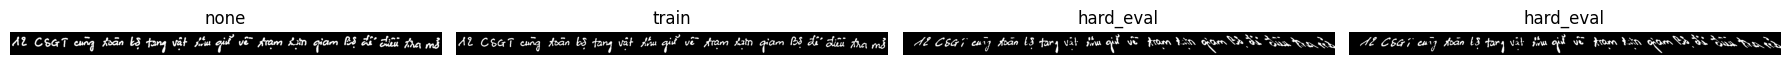

In [8]:
preview_row = train_df.sample(1, random_state=SEED).iloc[0]
preview_gray = cv2.imread(preview_row.path, cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, mode in zip(axes, ["none", "train", "hard_eval", "hard_eval"]):
    rng = np.random.default_rng(SEED if mode != "hard_eval" else SEED + 7)
    proc, _, _ = preprocess_for_legacy_crnn(
        gray=preview_gray,
        target_height=CFG["target_height"],
        max_width=CFG["max_width"],
        min_width=CFG["min_width"],
        required_width=preview_row.required_width,
        augment_mode=mode,
        rng=rng,
    )
    ax.imshow(proc[:, :, 0], cmap="gray")
    ax.set_title(mode)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [9]:
def decode_batch_predictions(predictions, input_length, decoder="greedy", beam_width=10):
    use_greedy = decoder == "greedy"
    decoded, _ = K.ctc_decode(predictions, input_length=input_length, greedy=use_greedy, beam_width=beam_width, top_paths=1)
    decoded = decoded[0].numpy()

    texts, confidences = [], []
    blank_idx = len(char_list)
    for i, seq in enumerate(decoded):
        tokens = [int(tok) for tok in seq if int(tok) != -1 and int(tok) != blank_idx]
        texts.append("".join(idx_to_char[tok] for tok in tokens))
        timestep_probs = np.max(predictions[i, : int(input_length[i]), :], axis=-1)
        timestep_probs = np.clip(timestep_probs, 1e-6, 1.0)
        conf = float(np.exp(np.mean(np.log(timestep_probs)))) if len(timestep_probs) else 0.0
        confidences.append(conf)
    return texts, confidences

def compute_ocr_metrics(pred_texts, gt_texts):
    cer_scores, wer_scores, ser_scores = [], [], []
    for pred, gt in zip(pred_texts, gt_texts):
        cer_scores.append(editdistance.eval(list(pred.lower()), list(gt.lower())) / max(1, len(gt)))
        wer_scores.append(editdistance.eval(pred.lower().split(), gt.lower().split()) / max(1, len(gt.split())))
        ser_scores.append(float(pred.strip() != gt.strip()))
    return {
        "cer": float(np.mean(cer_scores)) if cer_scores else 1.0,
        "wer": float(np.mean(wer_scores)) if wer_scores else 1.0,
        "ser": float(np.mean(ser_scores)) if ser_scores else 1.0,
        "exact_match_case_sensitive": float(np.mean([p.strip() == g.strip() for p, g in zip(pred_texts, gt_texts)])) if gt_texts else 0.0,
        "exact_match_case_insensitive": float(np.mean([p.strip().lower() == g.strip().lower() for p, g in zip(pred_texts, gt_texts)])) if gt_texts else 0.0,
    }

def ctc_lambda_func(args):
    y_pred, labels, input_length, label_length = args
    return K.ctc_batch_cost(labels, y_pred, input_length, label_length)

def build_crnn_ctc_model(num_chars: int, max_label_len: int):
    inputs = layers.Input(shape=(CFG["target_height"], None, 1), name="input_image")

    x = layers.Conv2D(64, (3, 3), padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPool2D(pool_size=(3, 2))(x)

    x = layers.Conv2D(128, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPool2D(pool_size=(2, 2))(x)

    x = layers.Conv2D(256, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.2)(x)
    x = layers.MaxPool2D(pool_size=(2, 1))(x)

    x = layers.Conv2D(256, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.2)(x)
    x = layers.MaxPool2D(pool_size=(2, 1))(x)

    x = layers.Conv2D(512, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPool2D(pool_size=(3, 1))(x)

    x = layers.Lambda(lambda t: tf.reshape(t, [tf.shape(t)[0], tf.shape(t)[2], tf.shape(t)[1] * tf.shape(t)[3]]))(x)
    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=0.25))(x)
    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=0.25))(x)
    outputs = layers.Dense(num_chars + 1, activation="softmax", dtype="float32")(x)

    inference_model = keras.Model(inputs=inputs, outputs=outputs, name="ocr_inference_model")

    labels = layers.Input(name="the_labels", shape=[max_label_len], dtype="int32")
    input_length = layers.Input(name="input_length", shape=[1], dtype="int32")
    label_length = layers.Input(name="label_length", shape=[1], dtype="int32")
    loss_out = layers.Lambda(ctc_lambda_func, name="ctc")([outputs, labels, input_length, label_length])
    training_model = keras.Model(inputs=[inputs, labels, input_length, label_length], outputs=loss_out, name="ocr_training_model")
    return inference_model, training_model

runtime_state = {"completed_epochs": 0, "resume_source": None}
max_label_len = int(records_df["encoded_length"].max())
num_chars = len(char_list)

tf.keras.backend.clear_session()

with strategy.scope():
    act_model, train_model = build_crnn_ctc_model(num_chars=num_chars, max_label_len=max_label_len)
    optimizer = keras.optimizers.Adam(learning_rate=CFG["initial_lr"], clipnorm=5.0)
    train_model.compile(loss={"ctc": lambda y_true, y_pred: y_pred}, optimizer=optimizer)

restored_from = None
if WEIGHTS_PATH is not None and Path(WEIGHTS_PATH).exists():
    act_model.load_weights(str(WEIGHTS_PATH))
    restored_from = str(WEIGHTS_PATH)

runtime_state["resume_source"] = restored_from
print("Restored from:", restored_from)


Restored from: /kaggle/input/models/trinhminhkhoak18hcm/ocr-train-chuan-checkpoint-weights/gguf/default/1/ocr-train-chuan_checkpoint.weights.h5


In [10]:
def resolve_fixed_width(df: pd.DataFrame, requested_width: int) -> int:
    required_floor = int(np.ceil(df["required_width"].max() / CFG["width_pad_multiple"]) * CFG["width_pad_multiple"])
    width = int(np.ceil(int(requested_width) / CFG["width_pad_multiple"]) * CFG["width_pad_multiple"])
    width = max(required_floor, width)
    width = min(CFG["max_width"], max(CFG["min_width"], width))
    return width

TRAIN_FIXED_WIDTH = resolve_fixed_width(train_df, CFG["fixed_train_width"])
EVAL_FIXED_WIDTH = resolve_fixed_width(pd.concat([val_df, camera_hard_df], ignore_index=True), CFG["fixed_eval_width"])

print("TRAIN_FIXED_WIDTH:", TRAIN_FIXED_WIDTH)
print("EVAL_FIXED_WIDTH :", EVAL_FIXED_WIDTH)
print("train clipped ratio:", round(float((train_df["final_width_hint"] > TRAIN_FIXED_WIDTH).mean()), 4))
print("val clipped ratio  :", round(float((val_df["final_width_hint"] > EVAL_FIXED_WIDTH).mean()), 4))

train_seq = OCRSequence(
    train_df,
    batch_size=CFG["global_batch_size"],
    max_label_len=max_label_len,
    target_height=CFG["target_height"],
    downsample_factor=CFG["downsample_factor"],
    max_width=CFG["max_width"],
    min_width=CFG["min_width"],
    width_pad_multiple=CFG["width_pad_multiple"],
    fixed_width=TRAIN_FIXED_WIDTH,
    augment_mode="train" if CFG["run_mode"] == "finetune" else "none",
    shuffle=True,
)

val_seq = OCRSequence(
    val_df,
    batch_size=CFG["global_batch_size"],
    max_label_len=max_label_len,
    target_height=CFG["target_height"],
    downsample_factor=CFG["downsample_factor"],
    max_width=CFG["max_width"],
    min_width=CFG["min_width"],
    width_pad_multiple=CFG["width_pad_multiple"],
    fixed_width=EVAL_FIXED_WIDTH,
    augment_mode="none",
    shuffle=False,
)

camera_hard_seq = OCRSequence(
    camera_hard_df,
    batch_size=CFG["global_batch_size"],
    max_label_len=max_label_len,
    target_height=CFG["target_height"],
    downsample_factor=CFG["downsample_factor"],
    max_width=CFG["max_width"],
    min_width=CFG["min_width"],
    width_pad_multiple=CFG["width_pad_multiple"],
    fixed_width=EVAL_FIXED_WIDTH,
    augment_mode="none" if camera_hard_mode == "real_camera" else "hard_eval",
    shuffle=False,
)

batch_inputs, _ = train_seq[0]
print("Train batch image shape:", batch_inputs["input_image"].shape)
act_model.summary()


TRAIN_FIXED_WIDTH: 1792
EVAL_FIXED_WIDTH : 1792
train clipped ratio: 0.0165
val clipped ratio  : 0.0128
Train batch image shape: (4, 96, 1792, 1)


Model: "ocr_inference_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 96, None, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, None, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, None, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 96, None, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, None, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, None, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, None, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, None, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, None, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, None, 256)  │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, None, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, None, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, None, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, None, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, None, 256)   │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, None, 256)   │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8, None, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, None, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, None, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, None, 512)   │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, None, 512)   │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 4, None, 512)   │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,407,965 (20.63 MB)

 Trainable params: 5,405,533 (20.62 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [11]:
def evaluate_sequence(model, sequence, tag: str, save_files: bool = True):
    rows = []
    total_pred_time = 0.0
    total_lines = 0

    for batch_idx in range(len(sequence)):
        batch_inputs, _ = sequence[batch_idx]
        batch_records = sequence.get_batch_records(batch_idx)
        images = batch_inputs["input_image"]
        input_length = batch_inputs["input_length"][:, 0]

        start = time.perf_counter()
        batch_pred = model.predict(images, verbose=0)
        total_pred_time += time.perf_counter() - start
        total_lines += len(images)

        pred_texts, confidences = decode_batch_predictions(
            batch_pred,
            input_length=input_length,
            decoder=CFG["decoder"],
            beam_width=CFG["beam_width"],
        )

        for row, pred_text, conf in zip(batch_records.itertuples(), pred_texts, confidences):
            gt = row.text
            rows.append(
                {
                    "filename": row.filename,
                    "path": row.path,
                    "ground_truth": gt,
                    "prediction": pred_text,
                    "confidence": conf,
                    "char_distance_lower": editdistance.eval(list(pred_text.lower()), list(gt.lower())),
                    "word_distance_lower": editdistance.eval(pred_text.lower().split(), gt.lower().split()),
                    "exact_match": int(pred_text.strip() == gt.strip()),
                }
            )

    results_df = pd.DataFrame(rows)
    metrics = compute_ocr_metrics(results_df["prediction"].tolist(), results_df["ground_truth"].tolist())
    metrics["avg_confidence"] = float(results_df["confidence"].mean()) if not results_df.empty else 0.0
    metrics["line_fps_batch_throughput"] = float(total_lines / max(total_pred_time, 1e-9))
    metrics["avg_line_latency_ms_batch"] = float((total_pred_time / max(total_lines, 1)) * 1000.0)
    metrics["num_eval_samples"] = int(len(results_df))
    metrics["tag"] = tag

    pred_path = None
    metrics_path = None
    if save_files:
        pred_path = PATHS["predictions_dir"] / f"{tag}_predictions.csv"
        metrics_path = PATHS["metrics_dir"] / f"{tag}_metrics.json"
        results_df.to_csv(pred_path, index=False, encoding="utf-8-sig")
        with open(metrics_path, "w", encoding="utf-8") as f:
            json.dump(metrics, f, ensure_ascii=False, indent=2)

    return results_df, metrics, pred_path, metrics_path

baseline_val_df, baseline_val_metrics, baseline_val_csv, baseline_val_json = evaluate_sequence(act_model, val_seq, "baseline_grouped_val", save_files=True)
baseline_hard_df, baseline_hard_metrics, baseline_hard_csv, baseline_hard_json = evaluate_sequence(act_model, camera_hard_seq, "baseline_camera_hard", save_files=True)

print("Baseline grouped val metrics:")
display(pd.DataFrame([baseline_val_metrics]).T.rename(columns={0: "value"}))
print("Baseline hard metrics:")
display(pd.DataFrame([baseline_hard_metrics]).T.rename(columns={0: "value"}))


I0000 00:00:1774007000.886493      67 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774007000.886502      66 cuda_dnn.cc:529] Loaded cuDNN version 91002


Baseline grouped val metrics:


,value
cer,0.021159
wer,0.055299
ser,0.285714
exact_match_case_sensitive,0.714286
exact_match_case_insensitive,0.730915
avg_confidence,0.984378
line_fps_batch_throughput,10.826274
avg_line_latency_ms_batch,92.367884
num_eval_samples,1323
tag,baseline_grouped_val


Baseline hard metrics:


,value
cer,0.565021
wer,0.883903
ser,0.886719
exact_match_case_sensitive,0.113281
exact_match_case_insensitive,0.113281
avg_confidence,0.950656
line_fps_batch_throughput,11.123137
avg_line_latency_ms_batch,89.902699
num_eval_samples,256
tag,baseline_camera_hard


In [12]:
def bundle_resume_artifacts():
    if PATHS["bundle_zip"].exists():
        PATHS["bundle_zip"].unlink()
    bundle_root = OUTPUT_ROOT / "bundle_payload"
    if bundle_root.exists():
        shutil.rmtree(bundle_root)
    bundle_root.mkdir(parents=True, exist_ok=True)

    payload_paths = [
        PATHS["config_json"],
        PATHS["profile_report_json"],
        PATHS["baseline_weights"],
        PATHS["balanced_weights"],
        PATHS["default_blend_weights"],
        PATHS["alpha20_weights"],
        PATHS["alpha50_weights"],
    ]
    for src in payload_paths:
        if src.exists():
            shutil.copy2(src, bundle_root / src.name)

    if PATHS["export_model"].exists():
        dst_model = bundle_root / "ocr_inference.keras"
        if dst_model.exists():
            if dst_model.is_dir():
                shutil.rmtree(dst_model)
            else:
                dst_model.unlink()
        if PATHS["export_model"].is_dir():
            shutil.copytree(PATHS["export_model"], dst_model)
        else:
            shutil.copy2(PATHS["export_model"], dst_model)

    shutil.make_archive(str(PATHS["bundle_zip"]).replace(".zip", ""), "zip", root_dir=bundle_root)
    return PATHS["bundle_zip"]

print("Profile-export notebook: build 3 deployment profiles from baseline and run-6 balanced-best.")


Profile-export notebook: build 3 deployment profiles from baseline and run-6 balanced-best.


In [13]:
def locate_from_resume(name: str):
    search_roots = []
    if RESUME_INPUT_ROOT is not None:
        search_roots.append(Path(RESUME_INPUT_ROOT))
    if RESUME_DIR is not None:
        search_roots.append(Path(RESUME_DIR).parent)
    for root in existing_search_roots():
        search_roots.append(root)

    seen = set()
    for root in search_roots:
        root = Path(root)
        key = str(root)
        if key in seen or not root.exists():
            continue
        seen.add(key)
        matches = sorted(root.rglob(name))
        if matches:
            return matches[0]
    return None

def evaluate_checkpoint(weight_path, split_tag: str, human_name: str, save_weights_to: Path | None = None):
    if weight_path is None:
        return None
    weight_path = Path(weight_path)
    if not weight_path.exists():
        return None

    act_model.load_weights(weight_path)
    grouped_df, grouped_metrics, _, _ = evaluate_sequence(act_model, val_seq, f"{split_tag}_grouped_val")
    hard_df, hard_metrics, _, _ = evaluate_sequence(act_model, camera_hard_seq, f"{split_tag}_camera_hard")
    if save_weights_to is not None:
        act_model.save_weights(save_weights_to)
    return {
        "tag": split_tag,
        "name": human_name,
        "weight_path": str(save_weights_to or weight_path),
        "grouped_df": grouped_df,
        "grouped_metrics": grouped_metrics,
        "hard_df": hard_df,
        "hard_metrics": hard_metrics,
    }

def snapshot_weights(weight_path):
    act_model.load_weights(weight_path)
    return [np.array(w, copy=True) for w in act_model.get_weights()]

resume_balanced = locate_from_resume("best_balanced.weights.h5")
print("resume_balanced =", resume_balanced)

if WEIGHTS_PATH is None or resume_balanced is None:
    raise FileNotFoundError(
        f"Khong tim thay baseline weight hoac best_balanced.weights.h5. "
        f"WEIGHTS_PATH={WEIGHTS_PATH}, RESUME_INPUT_ROOT={RESUME_INPUT_ROOT}, RESUME_DIR={RESUME_DIR}"
    )

baseline_candidate = evaluate_checkpoint(WEIGHTS_PATH, "profile_clean", "Profile clean: baseline", save_weights_to=PATHS["baseline_weights"])
balanced_candidate = evaluate_checkpoint(resume_balanced, "profile_robust", "Profile robust: balanced-best", save_weights_to=PATHS["balanced_weights"])

baseline_weights = snapshot_weights(WEIGHTS_PATH)
balanced_weights = snapshot_weights(resume_balanced)

blend_candidates = []
for alpha in CFG["blend_alpha_candidates"]:
    blended_weights = [
        ((1.0 - float(alpha)) * base_w) + (float(alpha) * bal_w)
        for base_w, bal_w in zip(baseline_weights, balanced_weights)
    ]
    act_model.set_weights(blended_weights)
    tag = f"profile_blend_a{int(round(alpha * 100)):02d}"
    grouped_df, grouped_metrics, _, _ = evaluate_sequence(act_model, val_seq, f"{tag}_grouped_val")
    hard_df, hard_metrics, _, _ = evaluate_sequence(act_model, camera_hard_seq, f"{tag}_camera_hard")

    save_path = None
    if abs(alpha - 0.20) < 1e-6:
        save_path = PATHS["alpha20_weights"]
    elif abs(alpha - 0.35) < 1e-6:
        save_path = PATHS["default_blend_weights"]
    elif abs(alpha - 0.50) < 1e-6:
        save_path = PATHS["alpha50_weights"]

    if save_path is not None:
        act_model.save_weights(save_path)

    blend_candidates.append(
        {
            "tag": tag,
            "name": f"Profile blend alpha={alpha:.2f}",
            "alpha": float(alpha),
            "weight_path": str(save_path) if save_path is not None else None,
            "grouped_df": grouped_df,
            "grouped_metrics": grouped_metrics,
            "hard_df": hard_df,
            "hard_metrics": hard_metrics,
        }
    )

all_candidates = [baseline_candidate, balanced_candidate] + blend_candidates

compare_rows = []
for candidate in all_candidates:
    compare_rows.append(
        {
            "model": candidate["name"],
            "split": "grouped_val",
            **candidate["grouped_metrics"],
        }
    )
    compare_rows.append(
        {
            "model": candidate["name"],
            "split": "camera_hard",
            **candidate["hard_metrics"],
        }
    )

compare_df = pd.DataFrame(compare_rows)
display(compare_df.reset_index(drop=True))

alpha35_candidate = next(c for c in blend_candidates if abs(c["alpha"] - CFG["default_export_alpha"]) < 1e-6)
profile_report = {
    "recommended_profiles": {
        "clean_paper": {
            "name": baseline_candidate["name"],
            "weight_path": baseline_candidate["weight_path"],
            "why": "Giay trang, anh tuong doi sach, can giu exact-match cao nhat.",
            "grouped_val_metrics": baseline_candidate["grouped_metrics"],
            "camera_hard_metrics": baseline_candidate["hard_metrics"],
        },
        "compromise_single_model": {
            "name": alpha35_candidate["name"],
            "weight_path": alpha35_candidate["weight_path"],
            "why": "Mot model can bang, clean gan baseline hon nhung hard tot hon ro.",
            "grouped_val_metrics": alpha35_candidate["grouped_metrics"],
            "camera_hard_metrics": alpha35_candidate["hard_metrics"],
        },
        "robust_bad_conditions": {
            "name": balanced_candidate["name"],
            "weight_path": balanced_candidate["weight_path"],
            "why": "Uu tien dieu kien xau, mo, toi, nhieu, rung tay.",
            "grouped_val_metrics": balanced_candidate["grouped_metrics"],
            "camera_hard_metrics": balanced_candidate["hard_metrics"],
        },
    },
    "blend_alpha_candidates": CFG["blend_alpha_candidates"],
}

with open(PATHS["profile_report_json"], "w", encoding="utf-8") as f:
    json.dump(profile_report, f, ensure_ascii=False, indent=2)

# Default export = compromise single-model profile.
act_model.load_weights(alpha35_candidate["weight_path"])
act_model.save(PATHS["export_model"])
bundle_resume_artifacts()

print("Default exported profile:", alpha35_candidate["name"])
print("Clean profile weight    :", PATHS["baseline_weights"])
print("Compromise profile weight:", PATHS["default_blend_weights"])
print("Robust profile weight   :", PATHS["balanced_weights"])
print("Optional alpha=0.20     :", PATHS["alpha20_weights"])
print("Optional alpha=0.50     :", PATHS["alpha50_weights"])

print("Worst grouped-val samples of compromise profile:")
display(
    alpha35_candidate["grouped_df"].sort_values(
        ["exact_match", "char_distance_lower", "word_distance_lower", "confidence"],
        ascending=[True, False, False, True],
    ).head(20)
)


resume_balanced = /kaggle/input/datasets/trinhminhkhoak18hcm/resume-bundle/best_balanced.weights.h5


,model,split,cer,wer,ser,exact_match_case_sensitive,exact_match_case_insensitive,avg_confidence,line_fps_batch_throughput,avg_line_latency_ms_batch,num_eval_samples,tag
0,Profile clean: baseline,grouped_val,0.021159,0.055299,0.285714,0.714286,0.730915,0.984378,11.109106,90.016244,1323,profile_clean_grouped_val
1,Profile clean: baseline,camera_hard,0.565021,0.883903,0.886719,0.113281,0.113281,0.950656,11.220857,89.119753,256,profile_clean_camera_hard
2,Profile robust: balanced-best,grouped_val,0.028007,0.076146,0.361300,0.638700,0.662132,0.982217,11.080775,90.246393,1323,profile_robust_grouped_val
3,Profile robust: balanced-best,camera_hard,0.387594,0.607158,0.882812,0.117188,0.121094,0.946562,11.090363,90.168377,256,profile_robust_camera_hard
4,Profile blend alpha=0.20,grouped_val,0.020698,0.055831,0.289494,0.710506,0.724112,0.984424,11.105881,90.042387,1323,profile_blend_a20_grouped_val
5,Profile blend alpha=0.20,camera_hard,0.517056,0.809780,0.894531,0.105469,0.109375,0.954229,11.013518,90.797505,256,profile_blend_a20_camera_hard
6,Profile blend alpha=0.35,grouped_val,0.020949,0.056665,0.297052,0.702948,0.718065,0.984318,11.058224,90.430433,1323,profile_blend_a35_grouped_val
7,Profile blend alpha=0.35,camera_hard,0.470926,0.735687,0.882812,0.117188,0.121094,0.957027,10.927507,91.512183,256,profile_blend_a35_camera_hard
8,Profile blend alpha=0.50,grouped_val,0.021994,0.059074,0.307634,0.692366,0.709751,0.984094,11.044059,90.546423,1323,profile_blend_a50_grouped_val
9,Profile blend alpha=0.50,camera_hard,0.443934,0.709217,0.878906,0.121094,0.125000,0.957106,11.157866,89.622873,256,profile_blend_a50_camera_hard


Default exported profile: Profile blend alpha=0.35
Clean profile weight    : /kaggle/working/ocr_profile_run/profile_clean_baseline.weights.h5
Compromise profile weight: /kaggle/working/ocr_profile_run/profile_compromise_a35.weights.h5
Robust profile weight   : /kaggle/working/ocr_profile_run/profile_robust_balanced.weights.h5
Optional alpha=0.20     : /kaggle/working/ocr_profile_run/profile_blend_a20.weights.h5
Optional alpha=0.50     : /kaggle/working/ocr_profile_run/profile_blend_a50.weights.h5
Worst grouped-val samples of compromise profile:


,filename,path,ground_truth,prediction,confidence,char_distance_lower,word_distance_lower,exact_match
318,27_220_1.jpg,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,hộ dân không thường trú tại xã Xuân Hải.,ộ ha thông thưng tra bi c huan hề,0.939927,16,9,0
1040,27_104_1.jpg,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,"họ đã sống cho lý tưởng, cống hiến tuổi xuân m...","họ đã sấy cho lý tưổng, cốg liến tuổi xuân mm...",0.954608,16,9,0
1210,1043_samples.png,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,"Số 19, ngõ 100, phố Sài Đồng, Phường Sài Đồng,...","Số 19, ngõ 100, phố IiĐn ưĐgiồng, Quận Long Bi...",0.933425,15,5,0
1320,7_86_1.jpg,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,"thể tại trạm 20 Trạm 20 đóng tại km 91, quốc l...","thể tại trạm 20 Trạm 20 đóng tại km 91, quốc l...",0.972457,14,5,0
505,7_253_1.jpg,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,Ban biên tập báo Tuổi Trẻ cũng quyết định gửi ...,Ban liên tập báo Tuổi Tủ cùng quyếnt đinh qiuả...,0.963848,12,8,0
1321,7_100_1.jpg,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,Cũng trong chương trình đẩy mạnh phát triển du...,Cũng trong chương trình đẩy mạnh phát triển du...,0.973711,12,4,0
1322,7_139_1.jpg,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,Cuộc sống sẽ chỉ cho bạn có những người đạt đư...,Cuộc sống sẽ chỉ cho bạn có những người đạt đư...,0.963321,12,3,0
554,31_40_1.jpg,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,TP và các ngành liên quan phải lưu ý các ý kiế...,Thvà cáu nghình loên quan phải lưu ý CC ý kiếu...,0.954285,11,10,0
928,27_153_1.jpg,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,nhưng do đặc điểm của thanh tra trong vụ này l...,nhưng do độc đểa của thanh tra trng vụ này là ...,0.958786,11,9,0
727,79_2.jpg,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,Phước Thiện 4 Phước Sơn Ninh Phước Ninh Thuận,Phước Thiện 4 Phước Sơn Ninh Thuận,0.989231,11,2,0


In [14]:
def prepare_line_for_model(image_or_path):
    if isinstance(image_or_path, (str, Path)):
        gray = cv2.imread(str(image_or_path), cv2.IMREAD_GRAYSCALE)
    else:
        arr = np.asarray(image_or_path)
        gray = cv2.cvtColor(arr, cv2.COLOR_BGR2GRAY) if arr.ndim == 3 else arr.copy()

    proc, _, final_width = preprocess_for_legacy_crnn(
        gray=gray,
        target_height=CFG["target_height"],
        max_width=CFG["max_width"],
        min_width=CFG["min_width"],
        required_width=None,
        augment_mode="none",
        rng=np.random.default_rng(0),
    )
    final_width = align_width(final_width, CFG["width_pad_multiple"])
    replica_batch = max(1, int(strategy.num_replicas_in_sync))
    batch = np.zeros((replica_batch, CFG["target_height"], final_width, 1), dtype=np.float32)
    for i in range(replica_batch):
        batch[i, :, : proc.shape[1], :] = proc
    input_length = np.full((replica_batch,), final_width // CFG["downsample_factor"], dtype=np.int32)
    return batch, input_length

def predict_line_text(image_or_path):
    batch, input_length = prepare_line_for_model(image_or_path)
    start = time.perf_counter()
    pred = act_model.predict(batch, verbose=0)
    elapsed_ms = (time.perf_counter() - start) * 1000.0
    texts, confs = decode_batch_predictions(pred, input_length=input_length, decoder=CFG["decoder"], beam_width=CFG["beam_width"])
    return {"text": texts[0], "confidence": confs[0], "latency_ms": elapsed_ms}

demo_clean = val_df.sample(1, random_state=SEED).iloc[0]
demo_hard = camera_hard_df.sample(1, random_state=SEED).iloc[0]

print("Clean demo :", demo_clean.filename, predict_line_text(demo_clean.path))
print("Hard demo  :", demo_hard.filename, predict_line_text(demo_hard.path))
print("Resume bundle:", PATHS["bundle_zip"])


Clean demo : 27_220_1.jpg {'text': 'ộ ha thông thưng tra bi c huan hề ', 'confidence': 0.5427646040916443, 'latency_ms': 2228.9104780002162}
Hard demo  : 271_25.jpg {'text': 'Nguyễn Thị Tần P6 Q5 Tp Hồ Chí Minh', 'confidence': 0.9831287860870361, 'latency_ms': 594.3925389999549}
Resume bundle: /kaggle/working/ocr_profile_run/resume_bundle.zip
